# ★ 주제 : 포켓몬 성향 4분면 분류 ★
- (비주류, 마스코트, 숨은 꿀픽, 슈퍼스타)
- 새로운 포켓몬 데이터를 입력 시 위의 4가지로 분류하는 모델
- 비주류 : 스텟도 낮고 인기도 없음
- 마스코드 : 스텟은 낮지만 인기는 많음
- 숨은 꿀픽 : 스텟은 준수하지만, 인기가 없어 잘 쓰지 않음
- 슈퍼스타 : 스텟과 인기 둘다 높음


# 1. 데이터 로드 및 초기 확인
- 모듈 import
- 데이터 로드 및 기본 구조와 통계량 확인

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [2]:
# 데이터 로드
df = pd.read_csv('./data/final_pokemon_data.csv', dtype={'dexnum': str})

# 1. 데이터 확인
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dexnum           1025 non-null   str    
 1   name             1025 non-null   str    
 2   korean name      1021 non-null   str    
 3   generation       1025 non-null   int64  
 4   type1            1025 non-null   str    
 5   type2            526 non-null    str    
 6   species          1025 non-null   str    
 7   height           1025 non-null   float64
 8   weight           1025 non-null   float64
 9   ability1         1025 non-null   str    
 10  ability2         858 non-null    str    
 11  hidden_ability   530 non-null    str    
 12  hp               1025 non-null   int64  
 13  attack           1025 non-null   int64  
 14  defense          1025 non-null   int64  
 15  sp_atk           1025 non-null   int64  
 16  sp_def           1025 non-null   int64  
 17  speed            1025 non

In [3]:
# 2. 데이터 통계 확인
print(df.describe())

        generation       height       weight           hp       attack  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      4.741463     1.211610    66.981659    70.184390    77.521951   
std       2.633633     1.248167   121.275372    26.631054    29.782541   
min       1.000000     0.100000     0.100000     1.000000     5.000000   
25%       3.000000     0.500000     8.500000    50.000000    55.000000   
50%       5.000000     1.000000    28.000000    68.000000    75.000000   
75%       7.000000     1.500000    70.000000    85.000000   100.000000   
max       9.000000    20.000000   999.900000   255.000000   181.000000   

           defense       sp_atk       sp_def        speed        total  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean     72.507317    70.080976    70.205854    67.186341   427.686829   
std      29.286972    29.658378    26.639329    28.717227   112.770735   
min       5.000000    10.000000    20

In [4]:
# 3. 결측치 확인
print(df.isnull().sum())

dexnum               0
name                 0
korean name          4
generation           0
type1                0
type2              499
species              0
height               0
weight               0
ability1             0
ability2           167
hidden_ability     495
hp                   0
attack               0
defense              0
sp_atk               0
sp_def               0
speed                0
total                0
ev_yield             0
catch_rate           0
base_friendship      0
base_exp             0
growth_rate          0
egg_group1           0
egg_group2         746
percent_male       155
percent_female     155
egg_cycles           0
special_group        0
Popularity           4
Evolution_Stage      0
is_evolved           0
dtype: int64


### 결측치 처리
- type2 결측치가 많기 때문에 type1과 병합하여 total_type라는 새로운 컬럼 생성

In [5]:
# 3. 결측치 처리-> type1과 type2 merge
# type2가 있으면 'type1/type2'로 합치고, 없으면 'type1'만 유지
def combine_types(row):
    # type2가 결측치(NaN)이면
    if pd.isna(row['type2']):
        return row['type1']
    else:
        return f"{row['type1']} / {row['type2']}"

# 새로운 컬럼 'total_type' 생성
df['total_type'] = df.apply(combine_types, axis=1)
df[['name', 'korean name', 'type1', 'type2', 'total_type']].head()


,name,korean name,type1,type2,total_type
0,Bulbasaur,이상해씨,Grass,Poison,Grass / Poison
1,Ivysaur,이상해풀,Grass,Poison,Grass / Poison
2,Venusaur,이상해꽃,Grass,Poison,Grass / Poison
3,Charmander,파이리,Fire,NaN,Fire
4,Charmeleon,리자드,Fire,NaN,Fire


# 2. 파생 변수 추가
- (1) 전설 여부 (is_legendary) 추가
- (2) 종족값 0 ~ 1 스케일링 (total_scaled) 추가 : 인기도와 비교하기 위한 사전 처리
- (3) 가성비 지수 (Efficiency_Tier) 추가 : 인기도 / 종족값 지수 (종족값 대비 인기도 확인)
- (4) 각각 포켓몬에 대해 라벨 추가(Target_Label) : 0=비주류, 1=마스코드, 2=숨은 꿀픽, 3=슈퍼스타
- (5) Stat_Specialization (스탯 특화도 / 분배 밸런스) 추가
- (6) Is_Dual_Type (이중 타입 여부) 추가
- (7) Physical_vs_Special (물리형 vs 특수형 성향 비율) 추가

In [6]:


# 파생 변수 추가

# (1) 전설 여부 (is_legendary) 추가
# Legendary, Mythical, Ultra Beast, Paradox 등을 전설급(1)으로 분류하고 나머지는 0으로 설정합니다.
legendary_categories = ['Legendary', 'Sub-Legendary', 'Mythical', 'Ultra Beast', 'Ancient Paradox', 'Future Paradox']
df['is_legendary'] = df['special_group'].apply(lambda x: 1 if x in legendary_categories else 0)

# (2) 종족값 0-1 스케일링 (total_scaled) 추가
# Min-Max Scaling: (현재값 - 최소값) / (최대값 - 최소값)
min_total = df['total'].min()
max_total = df['total'].max()
df['total_scaled'] = (df['total'] - min_total) / (max_total - min_total)

# (3) 가성비 지수 (Efficiency_Tier) 추가
# Popularity를 total_scaled로 나눈 값을 계산합니다.
# (참고: total_scaled가 0인 경우를 대비하여 아주 작은 값을 더하거나 예외처리를 할 수 있습니다.)
df['Efficiency_Tier'] = df['Popularity'] / df['total_scaled']

# 결과 확인
print(df[['name', 'korean name', 'total', 'total_scaled', 'Popularity', 'is_legendary', 'Efficiency_Tier']].head())

         name korean name  total  total_scaled  Popularity  is_legendary  \
0   Bulbasaur        이상해씨    318      0.262385    1.822630             0   
1     Ivysaur        이상해풀    405      0.422018   -0.085781             0   
2    Venusaur        이상해꽃    525      0.642202    1.542110             0   
3  Charmander         파이리    309      0.245872    2.084559             0   
4  Charmeleon         리자드    405      0.422018    1.510722             0   

   Efficiency_Tier  
0         6.946389  
1        -0.203263  
2         2.401286  
3         8.478243  
4         3.579754  


In [7]:

# 만약 앞서 코드에서 total_scaled를 만들지 않았다면 생성 (Min-Max Scaling)
if 'total_scaled' not in df.columns:
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    df['total_scaled'] = scaler.fit_transform(df[['total']])

# ----------------------------------------------------
# 1. Target_Label (4분면 분류를 위한 정답지 라벨링)
# ----------------------------------------------------
# 종족값과 인기도의 중앙값(Median)을 기준으로 4등분
stat_median = df['total_scaled'].median()
pop_median = df['Popularity'].median()

def assign_label(row):
    if row['total_scaled'] < stat_median and row['Popularity'] < pop_median:
        return 0 # 비주류 (Low Stat, Low Pop)
    elif row['total_scaled'] < stat_median and row['Popularity'] >= pop_median:
        return 1 # 마스코트 (Low Stat, High Pop)
    elif row['total_scaled'] >= stat_median and row['Popularity'] < pop_median:
        return 2 # 숨은 꿀픽 (High Stat, Low Pop)
    else:
        return 3 # 슈퍼스타 (High Stat, High Pop)

df['Target_Label'] = df.apply(assign_label, axis=1)

# ----------------------------------------------------
# 2. Stat_Specialization (스탯 특화도 / 분배 밸런스)
# ----------------------------------------------------
# 6족 스탯의 표준편차를 구하여 특정 스탯에 몰려있는지(특화), 고르게 분포되어있는지(밸런스) 수치화
stat_cols = ['hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed']
df['Stat_Specialization'] = df[stat_cols].std(axis=1)

# ----------------------------------------------------
# 3. Is_Dual_Type (이중 타입 여부)
# ----------------------------------------------------
# type2가 결측치가 아니면 1, 단일 타입이면 0
df['Is_Dual_Type'] = df['type2'].notna().astype(int)

# ----------------------------------------------------
# 4. Physical_vs_Special (물리형 vs 특수형 성향 비율)
# ----------------------------------------------------
# (공격 / 특수공격) 비율. 0으로 나누는 것을 방지하기 위해 분모에 아주 작은 값(1e-5) 추가
df['Physical_vs_Special'] = df['attack'] / (df['sp_atk'] + 1e-5)

# 생성된 파생 변수 결과 확인
display_cols = ['korean name', 'Target_Label', 'Stat_Specialization', 'Is_Dual_Type', 'Physical_vs_Special']
print("=== 파생 변수 생성 결과 ===")
display(df[display_cols].head())

# Target_Label (정답지) 분포 확인
print("\n=== Target Label 데이터 분포 ===")
print(df['Target_Label'].value_counts().sort_index())

=== 파생 변수 생성 결과 ===


,korean name,Target_Label,Stat_Specialization,Is_Dual_Type,Physical_vs_Special
0,이상해씨,1,9.465728,1,0.753846
1,이상해풀,0,9.751923,1,0.775000
2,이상해꽃,3,9.751923,1,0.820000
3,파이리,1,9.853933,0,0.866667
4,리자드,1,10.114346,0,0.800000



=== Target Label 데이터 분포 ===
Target_Label
0    298
1    203
2    211
3    313
Name: count, dtype: int64


In [8]:
df.head()

,dexnum,name,korean name,generation,type1,type2,species,height,weight,ability1,...,Evolution_Stage,is_evolved,total_type,is_legendary,total_scaled,Efficiency_Tier,Target_Label,Stat_Specialization,Is_Dual_Type,Physical_vs_Special
0,1,Bulbasaur,이상해씨,1,Grass,Poison,Seed Pokémon,0.7,6.9,Overgrow,...,0,0,Grass / Poison,0,0.262385,6.946389,1,9.465728,1,0.753846
1,2,Ivysaur,이상해풀,1,Grass,Poison,Seed Pokémon,1.0,13.0,Overgrow,...,1,1,Grass / Poison,0,0.422018,-0.203263,0,9.751923,1,0.775000
2,3,Venusaur,이상해꽃,1,Grass,Poison,Seed Pokémon,2.0,100.0,Overgrow,...,2,1,Grass / Poison,0,0.642202,2.401286,3,9.751923,1,0.820000
3,4,Charmander,파이리,1,Fire,NaN,Lizard Pokémon,0.6,8.5,Blaze,...,0,0,Fire,0,0.245872,8.478243,1,9.853933,0,0.866667
4,5,Charmeleon,리자드,1,Fire,NaN,Flame Pokémon,1.1,19.0,Blaze,...,1,1,Fire,0,0.422018,3.579754,1,10.114346,0,0.800000


In [9]:
# 전설 여부 변수 확인 및 생성 (기존에 생성하지 않았다면 실행)
legendary_categories = ['Legendary', 'Sub-Legendary', 'Mythical', 'Ultra Beast', 'Ancient Paradox', 'Future Paradox']
df['is_legendary'] = df['special_group'].apply(lambda x: 1 if x in legendary_categories else 0)

# 한글 폰트 설정 (환경에 따라 다를 수 있음. 기본적으로 맑은 고딕 등을 설정하거나 영어 레이블 사용)
# 여기서는 시각화의 가독성을 위해 영어 타입을 한글로 매핑하여 진행합니다.
type_map = {
    'Normal': '노말', 'Fire': '불꽃', 'Water': '물', 'Grass': '풀',
    'Electric': '전기', 'Ice': '얼음', 'Fighting': '격투', 'Poison': '독',
    'Ground': '땅', 'Flying': '비행', 'Psychic': '에스퍼', 'Bug': '벌레',
    'Rock': '바위', 'Ghost': '고스트', 'Dragon': '드래곤', 'Dark': '악',
    'Steel': '강철', 'Fairy': '페어리'
}

# 3. EDA 분석
- 상관계수 계산
- 종족값 / 인기도 별 분포 확인
- 종족값과 인기도를 세대에 따라 산점도로 표현
- 타입별 인기도
- 전설여부에 따른 인기도
- 인기도 Boxplot
- 타겟 변수 시각화
- 파생 변수 검증
- 이중 타입 및 물리/특수 성향 분석
- 도메인 지식 분석 (세대별 특징)

### 상관계수 계산
- 각 컬럼 별 상관계수 계산
- 포획률은 종족값이 높을수록 낮아짐 → 종족값이 높을수록 잡기 어려움
- height와 weight가 total 종족값과 비례하는 관계 확인
- 세대(Generation)에 따라 포켓몬의 4분면 성향(Target Label) 분포가 매우 극단적으로 치우쳐있음

### 파생변수 추가 작업해야할 사항

1. 세대(Generation) 변수의 범주화 및 파생 변수화
- 모델이 연속형 수치로 오해할 수 있는 상황 방지
- One-Hot Encoding 적용: generation 컬럼을 9개의 개별 컬럼(Gen_1_여부, Gen_2_여부...)으로 쪼개어 범주형 데이터로 변환
- is_gen_1 (1세대 여부) 파생 변수 생성
- 포켓몬이 1세대인지 아닌지(1 or 0)만 판별하는 파생 변수를 추가

2. 클래스 데이터 불균형(Class Imbalance) 처리
- 잘 모를 때 무조건 '비주류'로 찍는 편향된 예측 방지
- 리샘플링 (Resampling): 훈련 데이터(Train Set)에 한해 SMOTE 기법을 사용하여 부족한 클래스(예: 숨은 꿀픽, 슈퍼스타)의 데이터를 합성해 늘려주거나, 다수 클래스를 줄이는 Random Under-Sampling
- 가중치 부여 (Class Weights):내부 파라미터에 class_weight='balanced'를 설정하여 적은 수의 클래스를 맞췄을 때 모델에 더 큰 보상을 주도록 수정

3. 계층적 데이터 분할 (Stratified Split)
- 데이터를 훈련용(Train)과 테스트용(Test)으로 나눌 때 우연히 1세대 마스코트 포켓몬들이 테스트 셋에 몰려버리면 모델 학습이 제대로 이루어지지 않음
- stratify=y

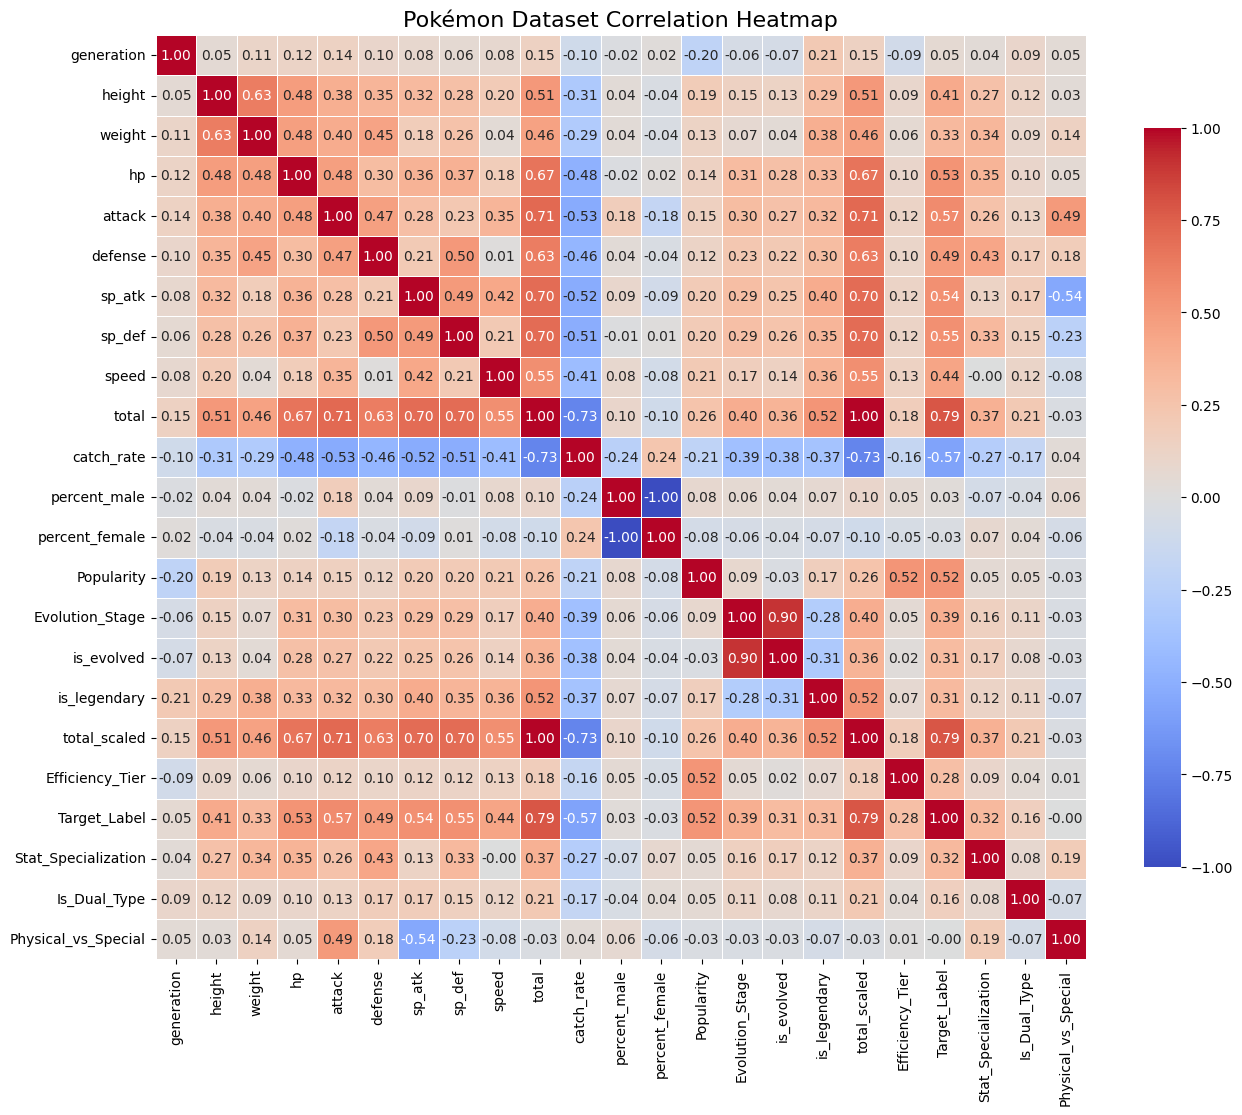

In [10]:

# 1. 상관계수 계산
corr_matrix = df.corr(numeric_only=True)

# 2. 히트맵 시각화 설정
plt.figure(figsize=(15, 12))  # 그래프 크기 조절 (변수가 많으므로 크게 설정)

# 3. 히트맵 그리기
sns.heatmap(corr_matrix, 
            annot=True,           # 각 칸에 숫자 표시
            fmt=".2f",            # 소수점 둘째 자리까지 표시
            cmap='coolwarm',      # 양의 상관관계(빨강), 음의 상관관계(파랑) 색상 조절
            linewidths=0.5,       # 칸 사이의 간격
            cbar_kws={"shrink": .8}) # 범례 크기 조절

plt.title('Pokémon Dataset Correlation Heatmap', fontsize=16)
plt.show()

### 종족값 / 인기도 별 분포 확인
- 종족값은 300과 500이 가장 많은 분포를 보임

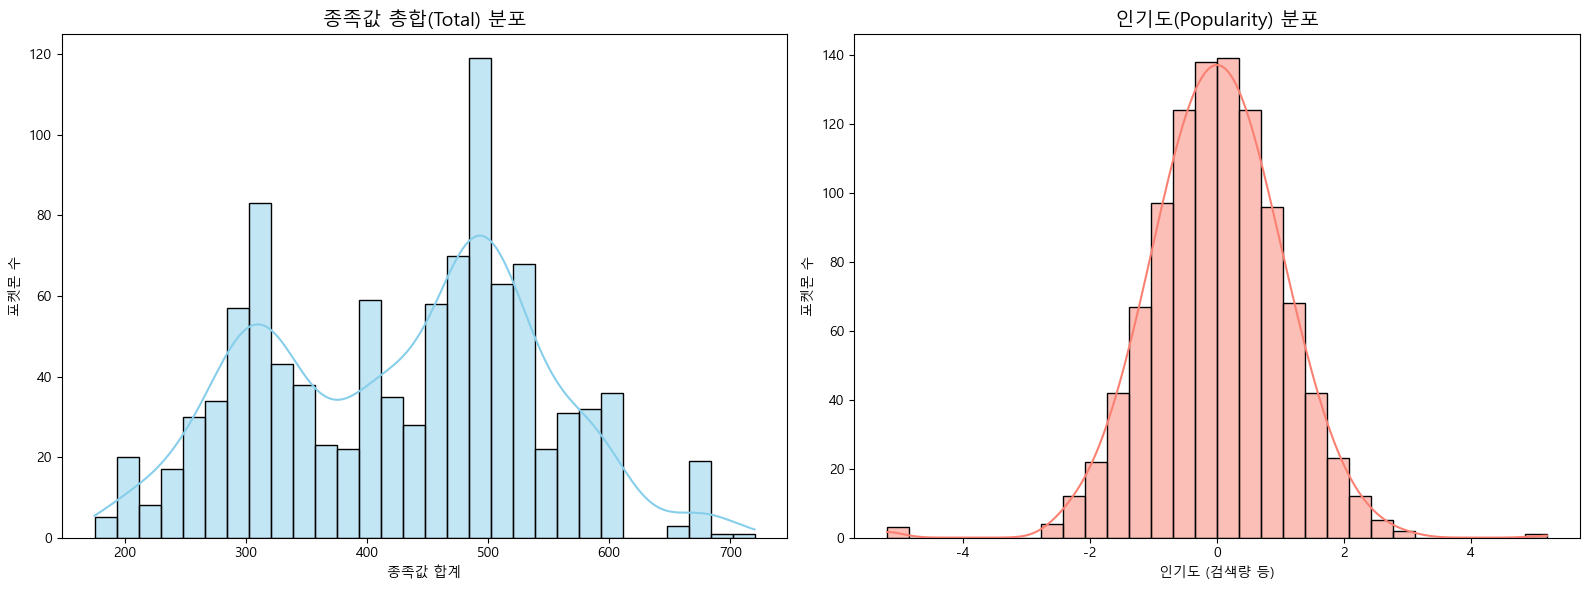

In [11]:


# 한글 폰트 설정 (환경에 따라 'AppleGothic' 또는 'Malgun Gothic')
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 그래프 레이아웃 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 종족값 총합(total) 분포
sns.histplot(df['total'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('종족값 총합(Total) 분포', fontsize=14)
axes[0].set_xlabel('종족값 합계')
axes[0].set_ylabel('포켓몬 수')

# 2. 인기도(Popularity) 분포
# 'popularity' 컬럼이 인기도 데이터라고 가정합니다.
sns.histplot(df['Popularity'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('인기도(Popularity) 분포', fontsize=14)
axes[1].set_xlabel('인기도 (검색량 등)')
axes[1].set_ylabel('포켓몬 수')

plt.tight_layout()
plt.show()

### 포켓몬 종족값 합계와 인기도의 상관관계
- 출시된 지 오래된 1~3세대 포켓몬들이 다른 세대 포켓몬들보다 인기도가 높은 것으로 판단됨
- 최근 출시된 세대는 상대적으로 인기도가 낮음

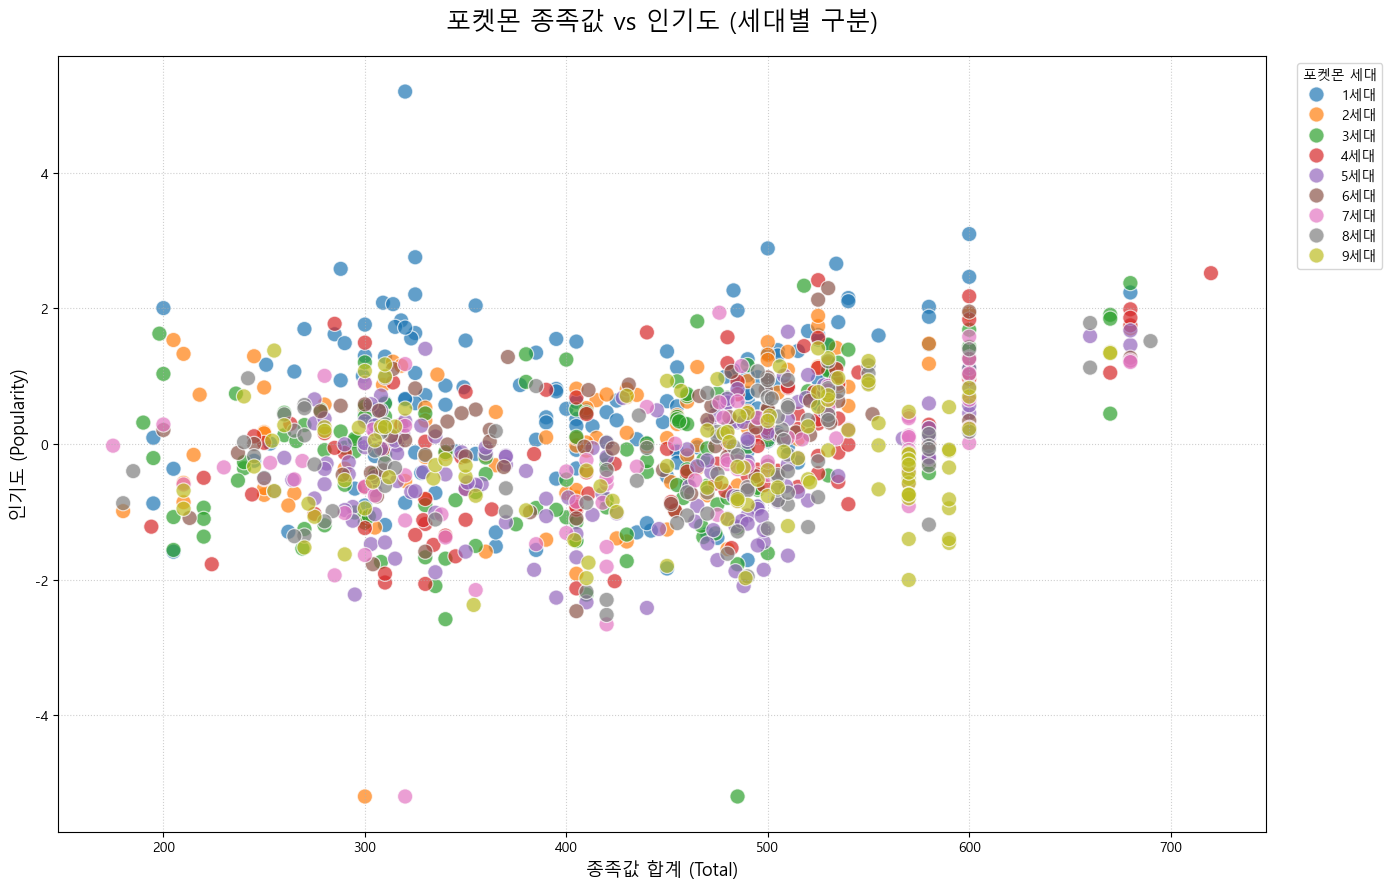

In [12]:


# 1. 세대 데이터를 문자열(str)로 변환하여 개별 범주로 인식하게 함
# 이렇게 해야 '1, 2, 3...' 각 세대가 고유한 색상을 가집니다.
df_plot = df.copy()
df_plot['generation'] = df_plot['generation'].astype(str) + "세대"

plt.figure(figsize=(14, 9))

# 2. 고유한 색상 팔레트 지정 (tab10 또는 husl 등 색 구분이 뚜렷한 것 사용)
sns.scatterplot(data=df_plot.sort_values('generation'), 
                x='total', y='Popularity', 
                hue='generation', 
                palette='tab10',   # 10가지 색상이 뚜렷하게 구분되는 팔레트
                alpha=0.7, 
                s=120,             # 점 크기를 조금 더 키움
                edgecolor='w')     # 점 테두리를 하얗게 해서 겹쳐도 보이게 함

# 3. 범례(Legend) 설정 보강
# 점이 많아 범례가 가려질 수 있으므로 그래프 바깥으로 뺍니다.
plt.legend(title='포켓몬 세대', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.title('포켓몬 종족값 vs 인기도 (세대별 구분)', fontsize=18, pad=20)
plt.xlabel('종족값 합계 (Total)', fontsize=13)
plt.ylabel('인기도 (Popularity)', fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 타입별 인기도
- 타입별 인기도를 분석하여 타입과 인기도가 상관관계가 있는지 확인
- 그래프 확인 시 드래곤 타입이 인기가 많은 것으로 확인
- 벌레타입이 인기가 없는 것으로 보아 외형적으로도 영향이 있는 것으로 보임

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_15144\1350838368.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_popularity, x='type_kr', y='Popularity', palette='viridis')


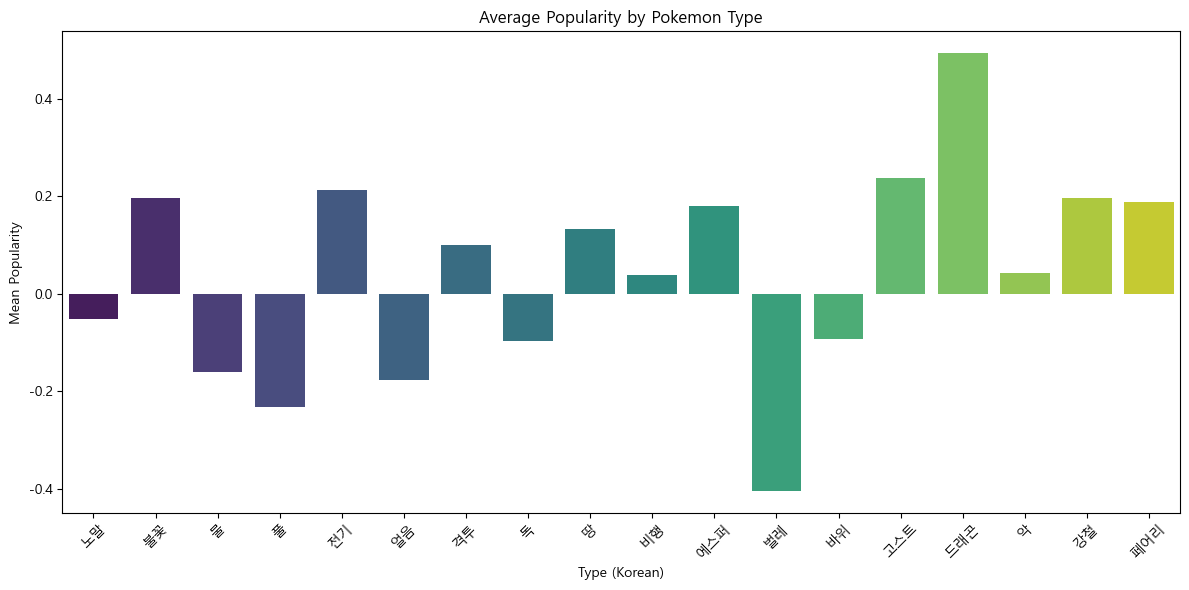

In [13]:
# --- Task 1. 타입별 인기도 (막대 그래프) ---
# 타입1과 타입2를 통합하여 계산
t1 = df[['type1', 'Popularity']].rename(columns={'type1': 'type'})
t2 = df[['type2', 'Popularity']].dropna(subset=['type2']).rename(columns={'type2': 'type'})
type_expanded = pd.concat([t1, t2])
type_expanded['type_kr'] = type_expanded['type'].map(type_map)

# 타입별 평균 인기도 계산
type_popularity = type_expanded.groupby('type_kr')['Popularity'].mean().reindex(type_map.values()).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=type_popularity, x='type_kr', y='Popularity', palette='viridis')
plt.title('Average Popularity by Pokemon Type')
plt.xlabel('Type (Korean)')
plt.ylabel('Mean Popularity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 전설여부에 따른 인기도
- 전설 포켓몬은 일반 포켓몬보다 상대적으로 성능이 좋음
- 성능이 좋고 쉽게 얻을 수 없으므로 일반 포켓몬보도 인기가 높은 것으로 확인

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_15144\1532254243.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=legendary_popularity, x='is_legendary', y='Popularity', palette='coolwarm')


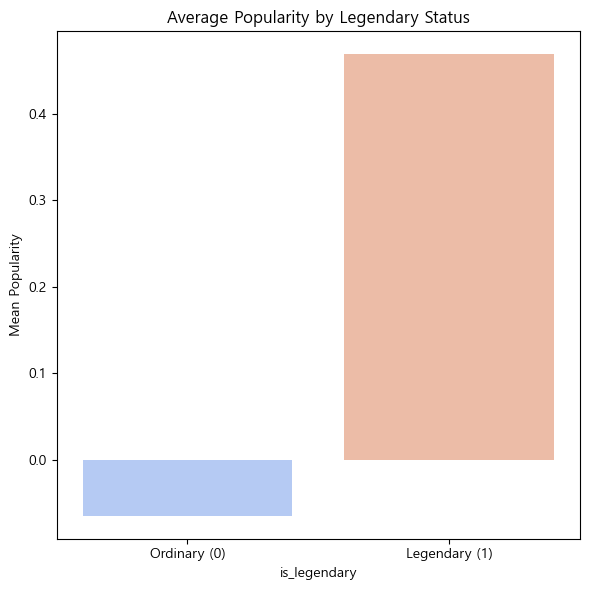

In [14]:
# --- Task 2. 전설여부에 따른 인기도 (막대 그래프) ---
legendary_popularity = df.groupby('is_legendary')['Popularity'].mean().reset_index()

plt.figure(figsize=(6, 6))
sns.barplot(data=legendary_popularity, x='is_legendary', y='Popularity', palette='coolwarm')
plt.title('Average Popularity by Legendary Status')
plt.xticks([0, 1], ['Ordinary (0)', 'Legendary (1)'])
plt.ylabel('Mean Popularity')
plt.tight_layout()
plt.show()

### 인기도 Boxplot

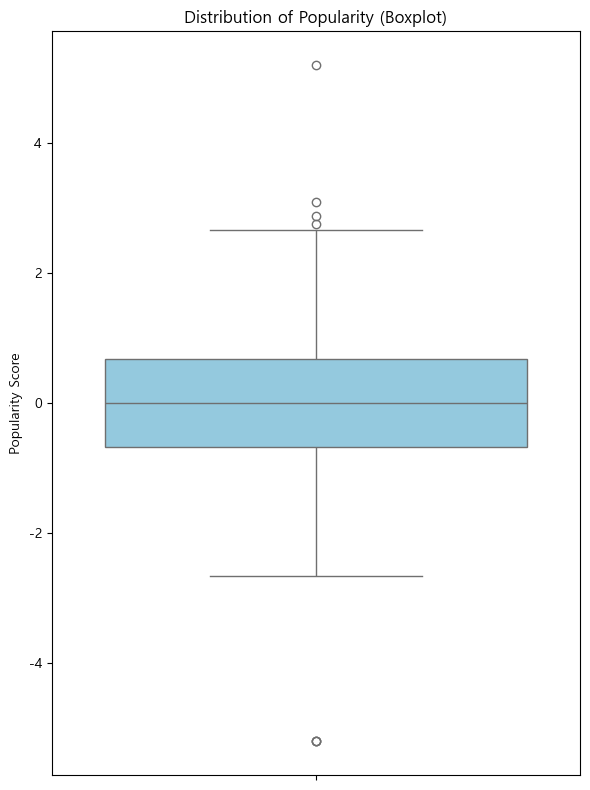

In [15]:
# --- Task 3. 인기도 Boxplot 생성 ---
plt.figure(figsize=(6, 8))
sns.boxplot(y='Popularity', data=df, color='skyblue')
plt.title('Distribution of Popularity (Boxplot)')
plt.ylabel('Popularity Score')
plt.tight_layout()
plt.show()

### 타겟 변수 시각화
- 인기도와 종족값 별 4개의 사분면으로 나누어 포켓몬의 라벨을 정함
1. 데이터 분포의 밀도
- 비주류(Grey) 영역에 가장 많은 데이터가 밀집. 대부분의 포켓몬이 평균적인 성능과 인지도를 가지고 있음을 시사
- 슈퍼스타(Red) 영역은 종족값이 높아질수록 인기도가 동반 상승하는 경향성을 띠고 있어, "강함이 곧 인기"로 이어지는 보편적 법칙이 관찰
2. 특이치 (Outliers)
- 마스코트(Orange) 영역 상단에 독보적으로 높게 솟은 점은 족값은 낮지만 인기도는 압도적인, 해당 프로젝트의 핵심 마스코트(예: 피카츄)일 가능성이 큼
- 숨은 꿀픽(Blue) 영역 하단에 성능은 높지만 인기도가 매우 낮은 데이터도 확인되는데, 디자인이나 접근성 문제로 외면받는 강력한 포켓몬일 수 있음

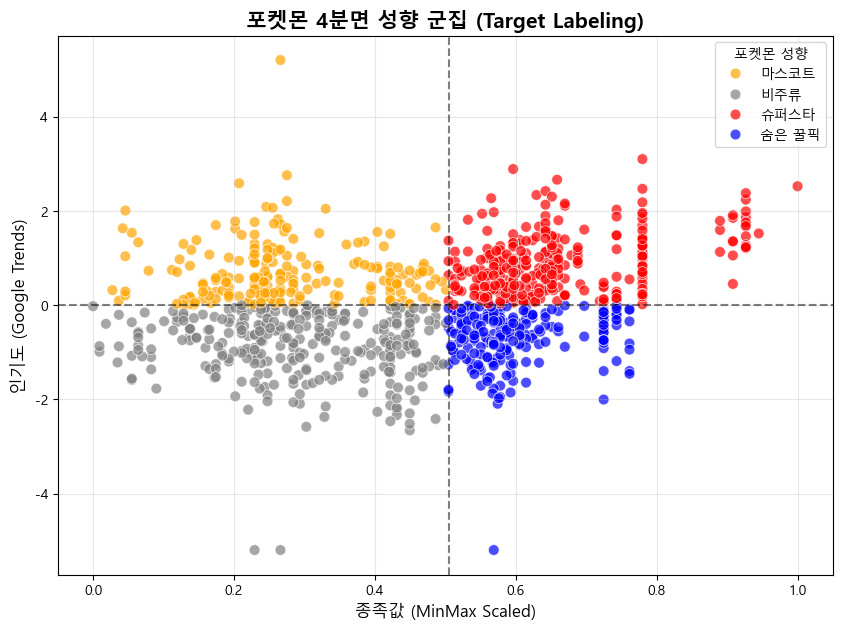

In [16]:
# --- [Phase 1] 타겟 변수 시각화 및 데이터 누수(Data Leakage) 방지 처리 ---
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

# 타겟 라벨에 이름 부여 (시각화용)
label_names = {0: '비주류', 1: '마스코트', 2: '숨은 꿀픽', 3: '슈퍼스타'}
df['Target_Name'] = df['Target_Label'].map(label_names)

# 1. 4분면 산점도 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, x='total_scaled', y='Popularity', hue='Target_Name',
    palette={'비주류': 'gray', '마스코트': 'orange', '숨은 꿀픽': 'blue', '슈퍼스타': 'red'},
    alpha=0.7, s=60
)

# 중앙값 기준선 그리기
plt.axvline(x=df['total_scaled'].median(), color='black', linestyle='--', alpha=0.5)
plt.axhline(y=df['Popularity'].median(), color='black', linestyle='--', alpha=0.5)

plt.title('포켓몬 4분면 성향 군집 (Target Labeling)', fontsize=15, fontweight='bold')
plt.xlabel('종족값 (MinMax Scaled)', fontsize=12)
plt.ylabel('인기도 (Google Trends)', fontsize=12)
plt.legend(title='포켓몬 성향')
plt.grid(True, alpha=0.3)
plt.show()

### 파생 변수 검증
- 진화 여부 및 스탯 특화도 분석
- 타겟 그룹별 진화 여부 누적 막대 그래프
- 타겟 그룹별 스탯 특화도 Boxplot

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_15144\354932372.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


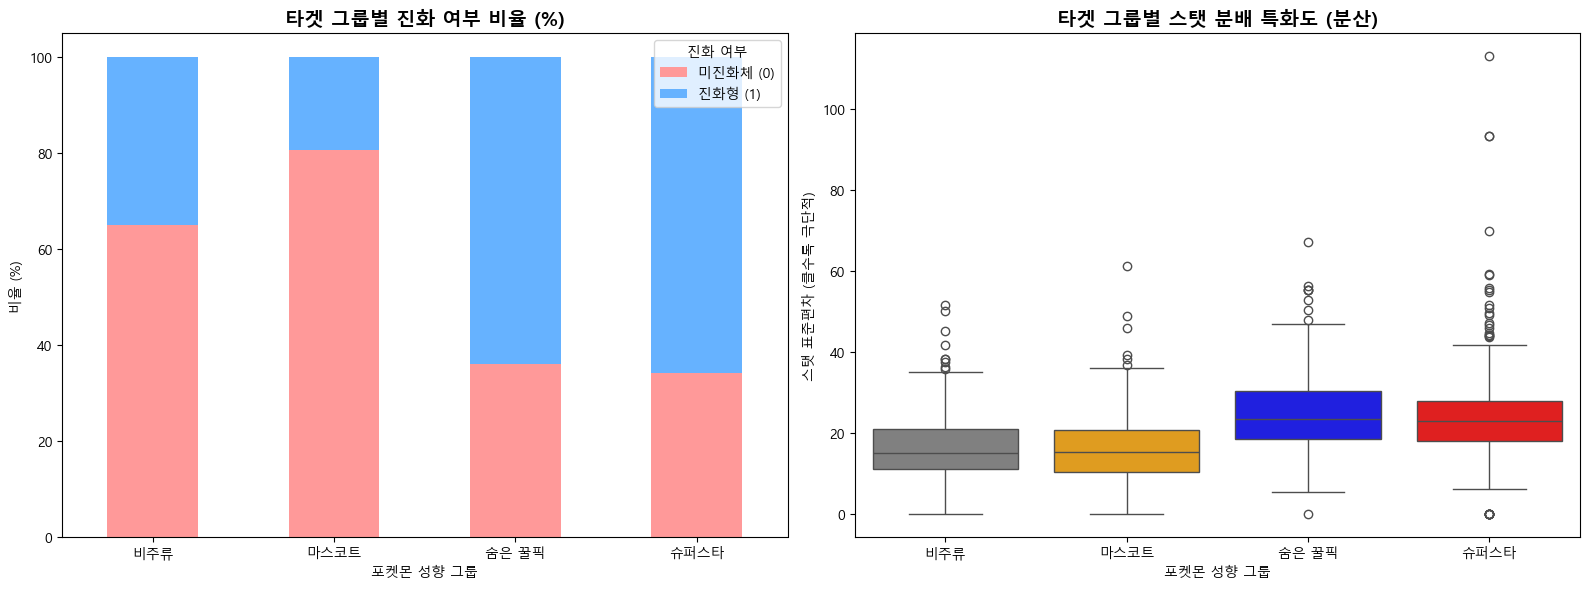

💡 [분석 결과]
1. 마스코트 그룹에서 미진화체의 비율이 다른 그룹에 비해 유의미하게 높은지 확인합니다.
2. 슈퍼스타나 숨은 꿀픽 그룹의 스탯 편차가 크다면, '선택과 집중'된 스탯이 모델 분류에 중요한 피처가 됩니다.


In [17]:
# --- [Phase 2] 파생 변수 검증: 진화 여부 및 스탯 특화도 분석 ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 타겟 그룹별 진화 여부 누적 막대 그래프 (마스코트는 미진화체가 많을까?)
# crosstab을 이용하여 그룹별 진화 여부 비율 계산
evo_crosstab = pd.crosstab(df['Target_Name'], df['is_evolved'], normalize='index') * 100
# 정렬 (비주류, 마스코트, 숨은 꿀픽, 슈퍼스타 순서)
evo_crosstab = evo_crosstab.reindex(['비주류', '마스코트', '숨은 꿀픽', '슈퍼스타'])

evo_crosstab.plot(kind='bar', stacked=True, ax=axes[0], color=['#FF9999', '#66B2FF'])
axes[0].set_title('타겟 그룹별 진화 여부 비율 (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xlabel('포켓몬 성향 그룹')
axes[0].legend(['미진화체 (0)', '진화형 (1)'], title='진화 여부')
axes[0].tick_params(axis='x', rotation=0)

# 2. 타겟 그룹별 스탯 특화도 Boxplot (성능이 좋은 그룹은 스탯이 극단적일까?)
sns.boxplot(
    data=df, x='Target_Name', y='Stat_Specialization', 
    order=['비주류', '마스코트', '숨은 꿀픽', '슈퍼스타'],
    palette={'비주류': 'gray', '마스코트': 'orange', '숨은 꿀픽': 'blue', '슈퍼스타': 'red'},
    ax=axes[1]
)
axes[1].set_title('타겟 그룹별 스탯 분배 특화도 (분산)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('포켓몬 성향 그룹')
axes[1].set_ylabel('스탯 표준편차 (클수록 극단적)')

plt.tight_layout()
plt.show()

print("💡 [분석 결과]")
print("1. 마스코트 그룹에서 미진화체의 비율이 다른 그룹에 비해 유의미하게 높은지 확인합니다.")
print("2. 슈퍼스타나 숨은 꿀픽 그룹의 스탯 편차가 크다면, '선택과 집중'된 스탯이 모델 분류에 중요한 피처가 됩니다.")

### 이중 타입 및 물리/특수 성향 분석
- '슈퍼스타' 그룹은 이중 타입이 약 60%를 넘어서는 반면, '마스코트'와 '비주류' 그룹은 단일 타입이 절반 이상을 차지
- 포켓몬이 물리형인지 특수형인지는 '슈퍼스타'나 '비주류'를 가르는 결정적인 요인이 아님

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_15144\422374323.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


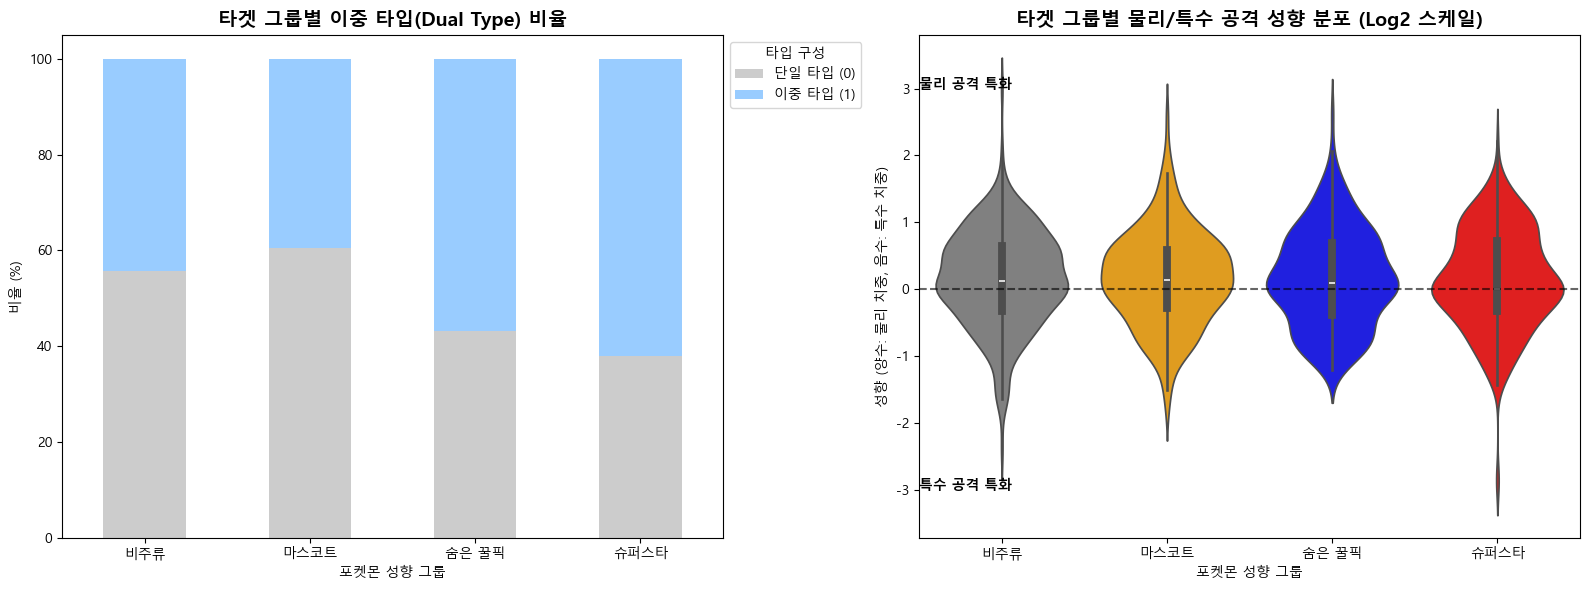

💡 [분석 결과 해석]
1. [이중 타입]: 슈퍼스타나 숨은 꿀픽 그룹에서 이중 타입(1)의 비율이 높다면, 다타입 견제폭이 실전 성능(라벨 분류)에 중요한 영향을 미친다는 것을 의미합니다.
2. [물리/특수]: Log2로 변환된 값이 0(점선)에 가까우면 쌍두형(물리/특수 둘다 사용), 위로 길면 물리 어태커, 아래로 길면 특수 어태커입니다. 특정 그룹의 바이올린 모양이 다르다면 모델이 이를 핵심 피처로 학습할 수 있습니다.


In [18]:
# --- [Phase 2-2] 파생 변수 추가 검증: 이중 타입 및 물리/특수 성향 분석 ---


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 타겟 그룹별 이중 타입(Is_Dual_Type) 비율 분석
dual_crosstab = pd.crosstab(df['Target_Name'], df['Is_Dual_Type'], normalize='index') * 100
dual_crosstab = dual_crosstab.reindex(['비주류', '마스코트', '숨은 꿀픽', '슈퍼스타'])

dual_crosstab.plot(kind='bar', stacked=True, ax=axes[0], color=['#CCCCCC', '#99CCFF'])
axes[0].set_title('타겟 그룹별 이중 타입(Dual Type) 비율', fontsize=14, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xlabel('포켓몬 성향 그룹')
axes[0].legend(['단일 타입 (0)', '이중 타입 (1)'], title='타입 구성', loc='upper left', bbox_to_anchor=(1, 1))
axes[0].tick_params(axis='x', rotation=0)

# 2. 타겟 그룹별 물리 vs 특수 성향 분석 (Violin Plot)
# 비율 데이터 정규화를 위해 Log2 변환 (0 = 밸런스형, 양수 = 물리형, 음수 = 특수형)
df['log2_Phys_vs_Spec'] = np.log2(df['Physical_vs_Special'] + 1e-5)

sns.violinplot(
    data=df, x='Target_Name', y='log2_Phys_vs_Spec',
    order=['비주류', '마스코트', '숨은 꿀픽', '슈퍼스타'],
    palette={'비주류': 'gray', '마스코트': 'orange', '숨은 꿀픽': 'blue', '슈퍼스타': 'red'},
    ax=axes[1]
)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.6) # 물리/특수 밸런스 기준선
axes[1].set_title('타겟 그룹별 물리/특수 공격 성향 분포 (Log2 스케일)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('포켓몬 성향 그룹')
axes[1].set_ylabel('성향 (양수: 물리 치중, 음수: 특수 치중)')

# 바이올린 플롯에 부가 설명 텍스트 추가
axes[1].text(-0.5, 3, '물리 공격 특화 ', color='black', fontsize=10, weight='bold')
axes[1].text(-0.5, -3, '특수 공격 특화 ', color='black', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print("💡 [분석 결과 해석]")
print("1. [이중 타입]: 슈퍼스타나 숨은 꿀픽 그룹에서 이중 타입(1)의 비율이 높다면, 다타입 견제폭이 실전 성능(라벨 분류)에 중요한 영향을 미친다는 것을 의미합니다.")
print("2. [물리/특수]: Log2로 변환된 값이 0(점선)에 가까우면 쌍두형(물리/특수 둘다 사용), 위로 길면 물리 어태커, 아래로 길면 특수 어태커입니다. 특정 그룹의 바이올린 모양이 다르다면 모델이 이를 핵심 피처로 학습할 수 있습니다.")

### 도메인 지식 분석 (세대별 특징)
- 1세대는 '마스코트(60)' 그룹에서 다른 모든 세대를 통틀어 압도적으로 높은 수치를 기록하고 있습니다. 또한 '슈퍼스타(52)' 역시 전 세대 중 가장 많음
- 5세대는 '비주류(60)' 포켓몬이 전 세대 중 가장 많습니다. 3세대 역시 '비주류'가 52로 상당히 높음
- 9세대의 '숨은 꿀픽' 수치가 45로 전 세대 중 가장 높게 나타남
- 인기와 성능을 모두 거머쥔 최상위 티어 포켓몬들은 특정 세대에만 편중되지 않습니다. 각 세대마다 그 시대를 대표하는 '슈퍼스타'급 포켓몬들이 일정한 비율로 성공적으로 기획 및 배출

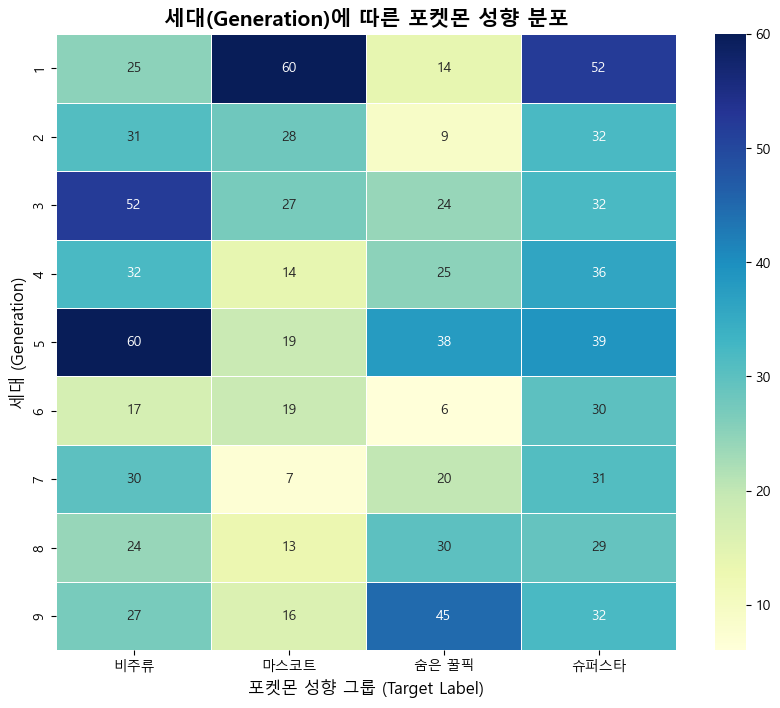

In [19]:
# --- [Phase 3] 도메인 특성 분석: 세대(Generation)별 타겟 라벨 분포 ---

# 세대별로 어떤 타겟 라벨이 많이 분포하는지 교차표 생성
gen_crosstab = pd.crosstab(df['generation'], df['Target_Name'])

# 컬럼 순서 정렬
gen_crosstab = gen_crosstab[['비주류', '마스코트', '숨은 꿀픽', '슈퍼스타']]

plt.figure(figsize=(10, 8))
# Heatmap으로 세대별 그룹 밀집도 시각화
sns.heatmap(gen_crosstab, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)

plt.title('세대(Generation)에 따른 포켓몬 성향 분포', fontsize=15, fontweight='bold')
plt.xlabel('포켓몬 성향 그룹 (Target Label)', fontsize=12)
plt.ylabel('세대 (Generation)', fontsize=12)
plt.show()

# 4. 학습 데이터 준비 및 누수 방지

In [21]:
# --- [1 & 3] 데이터 전처리 및 학습 세트 준비

# 1. 원본 데이터프레임(df)에서 특수 문자 및 무한대 처리
# (분석 과정에서 생긴 '—'나 'inf'를 NaN으로 변환)
df = df.replace(['—', 'inf', '-inf'], np.nan)

# 2. 히트맵 인사이트 반영: 1세대 여부 파생 변수 확정
df['is_gen_1'] = (df['generation'] == 1).astype(int)

# 3. 범주형 변수 원핫 인코딩 (여기서 df_ml이 생성됩니다)
# 모델이 학습할 수 있도록 'generation'과 'type1'을 숫자로 변환
df_ml = pd.get_dummies(df, columns=['generation', 'type1'], drop_first=True)

# 4. 학습 데이터(X)와 정답(y) 분리
# 데이터 누수(Data Leakage)를 막기 위해 타겟 생성에 쓰인 모든 변수 제외
drop_features = [
    'Target_Label', 'Target_Name', 'dexnum', 'name', 'korean name', 
    'total', 'total_scaled', 'Popularity', 'type2', 'species', 
    'ability1', 'ability2', 'hidden_ability', 'ev_yield', 
    'catch_rate', 'base_friendship', 'base_exp', 'growth_rate', 
    'egg_group1', 'egg_group2', 'special_group', 'egg_cycles',
    'percent_male', 'percent_female', 'log2_Phys_vs_Spec'
]

# df_ml에서 학습에 불필요한 컬럼 제거
X = df_ml.drop(columns=[c for c in drop_features if c in df_ml.columns])
y = df_ml['Target_Label']

# 5. 수치 데이터 강제 변환 및 최종 결측치 처리 (TypeError 방지)
X = X.apply(pd.to_numeric, errors='coerce') # 모든 데이터를 숫자로 변환
X = X.fillna(X.median())                    # 숫자로 변환된 후 중앙값으로 결측치 처리
X = X.replace([np.inf, -np.inf], 0)         # 혹시 모를 무한대 값 처리

# 6. 계층적 데이터 분할 (Stratified Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"1. 데이터 준비 완료 (df_ml 생성됨)")
print(f"2. 학습 피처 수: {X_train.shape[1]}개")
print(f"3. 훈련 데이터 수: {len(X_train)}개, 테스트 데이터 수: {len(X_test)}개")

1. 데이터 준비 완료 (df_ml 생성됨)
2. 학습 피처 수: 42개
3. 훈련 데이터 수: 820개, 테스트 데이터 수: 205개


# 5. 모델 선정 및 비교 학습
- 랜덤 포레스트와 XGBoost 중 어떤 것이 더 성능이 잘 나올지 비교

In [25]:
# 1. Random Forest (클래스 불균형 처리 포함)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 2. XGBoost (비지도 학습 기반의 고성능 모델)
xgb_model = XGBClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

print("두 모델의 학습이 성공적으로 완료되었습니다.")

두 모델의 학습이 성공적으로 완료되었습니다.


# 6. 모델 성능 평가 및 시각화
- 랜덤 포레스트가 XGBoost보다 f1-score가 더 높게 나옴 -> 랜덤 포레스트 선택


[Random Forest] 성능 평가 리포트
              precision    recall  f1-score   support

         비주류       0.95      0.93      0.94        60
        마스코트       0.97      0.85      0.91        41
       숨은 꿀픽       0.91      0.93      0.92        42
        슈퍼스타       0.91      0.98      0.95        62

    accuracy                           0.93       205
   macro avg       0.93      0.92      0.93       205
weighted avg       0.93      0.93      0.93       205



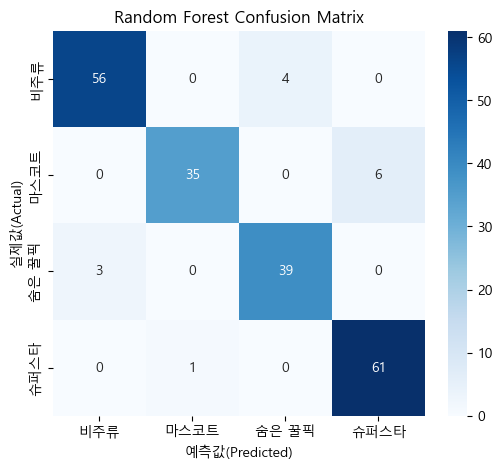


[XGBoost] 성능 평가 리포트
              precision    recall  f1-score   support

         비주류       0.92      0.93      0.93        60
        마스코트       0.95      0.90      0.93        41
       숨은 꿀픽       0.90      0.88      0.89        42
        슈퍼스타       0.94      0.97      0.95        62

    accuracy                           0.93       205
   macro avg       0.93      0.92      0.92       205
weighted avg       0.93      0.93      0.93       205



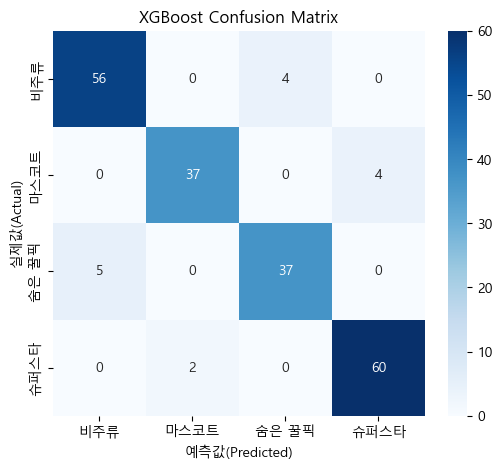

In [26]:
# --- [4] 성능 지표 리포트 및 혼동 행렬 시각화 ---
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

target_names = ['비주류', '마스코트', '숨은 꿀픽', '슈퍼스타']

def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    print(f"\n[{title}] 성능 평가 리포트")
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    # 혼동 행렬 (Confusion Matrix)
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{title} Confusion Matrix')
    plt.ylabel('실제값(Actual)')
    plt.xlabel('예측값(Predicted)')
    plt.show()

# 두 모델의 성능 비교 출력
evaluate_model(rf_model, X_test, y_test, "Random Forest")
evaluate_model(xgb_model, X_test, y_test, "XGBoost")

# 7. 최종 모델 선정 및 하이퍼파라미터 튜닝
- 선정 모델 : 랜덤 포레스트
- 최적의 하이퍼 파라미터 : {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}

In [28]:
# --- [5] 최종 모델 선정 및 하이퍼파라미터 튜닝 (Random Forest) ---

# 1. 탐색할 하이퍼파라미터 범위 설정
# n_estimators: 나무의 개수
# max_depth: 트리의 최대 깊이
# min_samples_split: 노드를 분할하기 위한 최소 샘플 수
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced'] # 클래스 불균형 유지를 위해 고정
}

# 2. 그리드 서치(GridSearchCV) 객체 생성
# cv=5: 5-폴드 교차 검증을 통해 가장 안정적인 파라미터를 찾음
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_macro', # 불균형 데이터이므로 f1_macro 점수를 기준으로 최적화
    n_jobs=-1 # 모든 CPU 코어 사용
)

print("랜덤 포레스트 최적 파라미터 탐색 시작 (시간이 다소 소요될 수 있습니다)...")
grid_rf.fit(X_train, y_train)

# 3. 최적의 모델 추출
final_rf_model = grid_rf.best_estimator_

print(f"최적 파라미터: {grid_rf.best_params_}")
print(f"최고 F1-Score: {grid_rf.best_score_:.4f}")

# 4. 최종 모델 성능 평가 (Test Set)
from sklearn.metrics import classification_report, confusion_matrix

y_pred_final = final_rf_model.predict(X_test)
print("\n=== [최종 모델] Optimized Random Forest 평가 결과 ===")
print(classification_report(y_test, y_pred_final, target_names=['비주류', '마스코트', '숨은 꿀픽', '슈퍼스타']))

랜덤 포레스트 최적 파라미터 탐색 시작 (시간이 다소 소요될 수 있습니다)...
최적 파라미터: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
최고 F1-Score: 0.9506

=== [최종 모델] Optimized Random Forest 평가 결과 ===
              precision    recall  f1-score   support

         비주류       0.96      0.88      0.92        60
        마스코트       0.97      0.83      0.89        41
       숨은 꿀픽       0.85      0.95      0.90        42
        슈퍼스타       0.90      0.98      0.94        62

    accuracy                           0.92       205
   macro avg       0.92      0.91      0.91       205
weighted avg       0.92      0.92      0.92       205



# 9. 최종 모델 피처 중요도(Feature Importance) 시각화
- 가성비 지수가 압도적인 성능을 보임
- 스텟 값들도 유의미한 중요도가 보임

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_15144\932092704.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='magma')


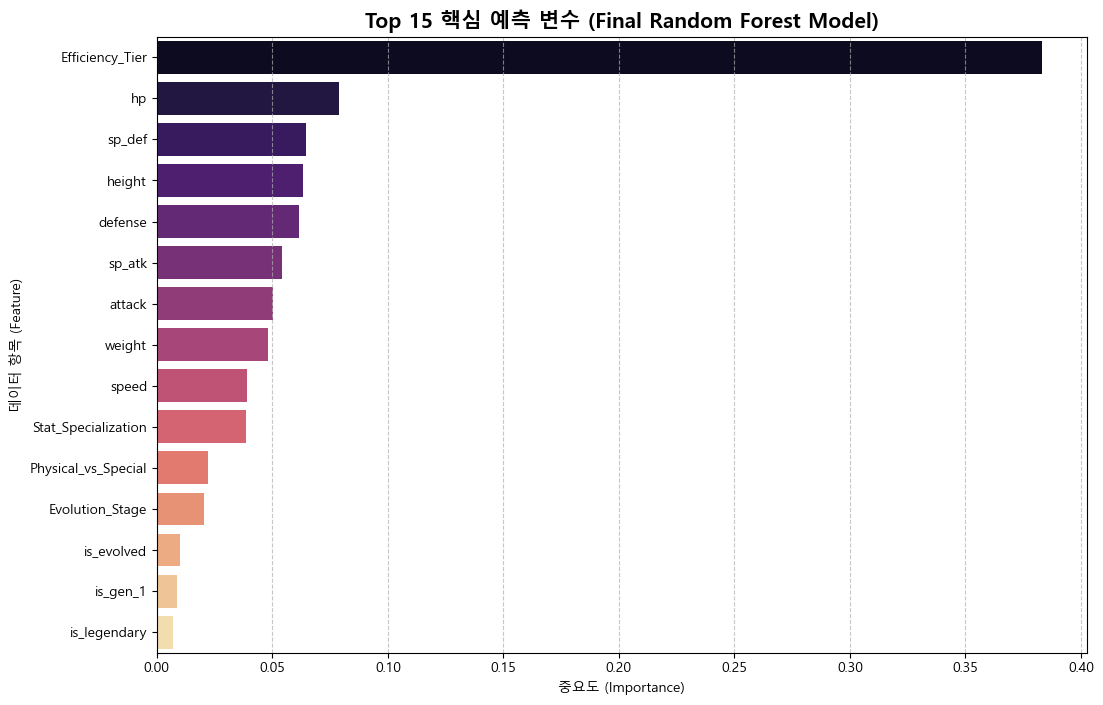

💡 [분석 인사이트]
가장 중요한 변수: 'Efficiency_Tier'
이 결과는 포켓몬의 성향(4분면 그룹)을 결정짓는 데 해당 데이터가 가장 결정적인 역할을 했음을 보여줍니다.


In [29]:
# --- [6] 최종 모델의 피처 중요도(Feature Importance) 시각화 ---
importances = final_rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 중요도 순으로 정렬 후 상위 15개 추출
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='magma')
plt.title('Top 15 핵심 예측 변수 (Final Random Forest Model)', fontsize=15, fontweight='bold')
plt.xlabel('중요도 (Importance)')
plt.ylabel('데이터 항목 (Feature)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 인사이트 출력 예시
print("💡 [분석 인사이트]")
print(f"가장 중요한 변수: '{top_15_features.iloc[0]['Feature']}'")
print("이 결과는 포켓몬의 성향(4분면 그룹)을 결정짓는 데 해당 데이터가 가장 결정적인 역할을 했음을 보여줍니다.")

# 결과 : 가상의 포켓몬 그룹 예측기

In [80]:
def predict_custom_pokemon(model, features_dict, pokemon_name="가상 포켓몬"):
    """
    이름과 특징을 입력받아 포켓몬 성향을 예측하는 함수
    """
    # 1. 학습 데이터 구조와 동일한 데이터프레임 생성
    new_pkm = pd.DataFrame([features_dict])
    
    # 2. 원핫 인코딩 컬럼 맞추기 (학습 때 없던 컬럼은 0으로 채움)
    for col in X_train.columns:
        if col not in new_pkm.columns:
            new_pkm[col] = 0
            
    # 3. 컬럼 순서 고정
    X_new = new_pkm[X_train.columns]
    
    # 4. 예측 수행
    pred = model.predict(X_new)[0]
    prob = model.predict_proba(X_new)[0]
    
    label_names = {0: '비주류', 1: '마스코트', 2: '숨은 꿀픽', 3: '슈퍼스타'}
    result_name = label_names[pred]
    
    # 5. 결과 출력
    print(f"============================================")
    print(f"🔍 [분석 결과] '{pokemon_name}' 포켓몬")
    print(f"============================================")
    print(f"이 포켓몬은 [{result_name}] 그룹에 속할 가능성이 가장 높습니다!")
    print(f"\n[상세 확률 분포]")
    for i, name in label_names.items():
        print(f"- {name}: {prob[i]:.1%}")
    print(f"============================================")

# --- 사용 예시 ---
# 내가 정한 이름과 스탯 입력
my_pkm_name = "포뭉이"  # <-- 여기에 원하는 이름을 적으세요!
my_pkm_features = {
    'hp': np.random.randint(30, 160),
    'attack': np.random.randint(30, 160), 
    'defense': np.random.randint(30, 160), 
    'sp_atk': np.random.randint(30, 160), 
    'sp_def': np.random.randint(30, 160), 
    'speed': np.random.randint(30, 160),
    'Evolution_Stage': 0, 
    'is_evolved': 0,
    'is_gen_1': 0, 
    'Stat_Specialization': 40.5, # 스텟 편차
    'Is_Dual_Type': 1,
    'Physical_vs_Special': 1.0,
    'type1_Dragon': 1 
}

# 함수 실행
predict_custom_pokemon(final_rf_model, my_pkm_features, my_pkm_name)

🔍 [분석 결과] '포뭉이' 포켓몬
이 포켓몬은 [숨은 꿀픽] 그룹에 속할 가능성이 가장 높습니다!

[상세 확률 분포]
- 비주류: 17.9%
- 마스코트: 9.9%
- 숨은 꿀픽: 37.5%
- 슈퍼스타: 34.7%


###  200마리의 가상 포켓몬을 생성하여 분류가 어떻게 되었는지 확인
- 가상의 포켓몬은 어떤 타입과 진화 조건인지 자세히 모르므로 슈퍼스타와 마스코트가 잘 나오지 않는 모습이 보임
- 반면, 랜덤으로 스텟을 설정하다 보니 적당한 스텟이 분배되어 있는 숨은 꿀픽이 많이 나왔고, 스텟이 낮게 나왔다면 비주류도 적당히 나온 모습이 보임
- 추후 10세대의 포켓몬 도감이 구성된다면, 그 데이터를 크롤링해 어떤 분포가 많은지 볼 수 있는 유의미한 데이터가 될 것 같음

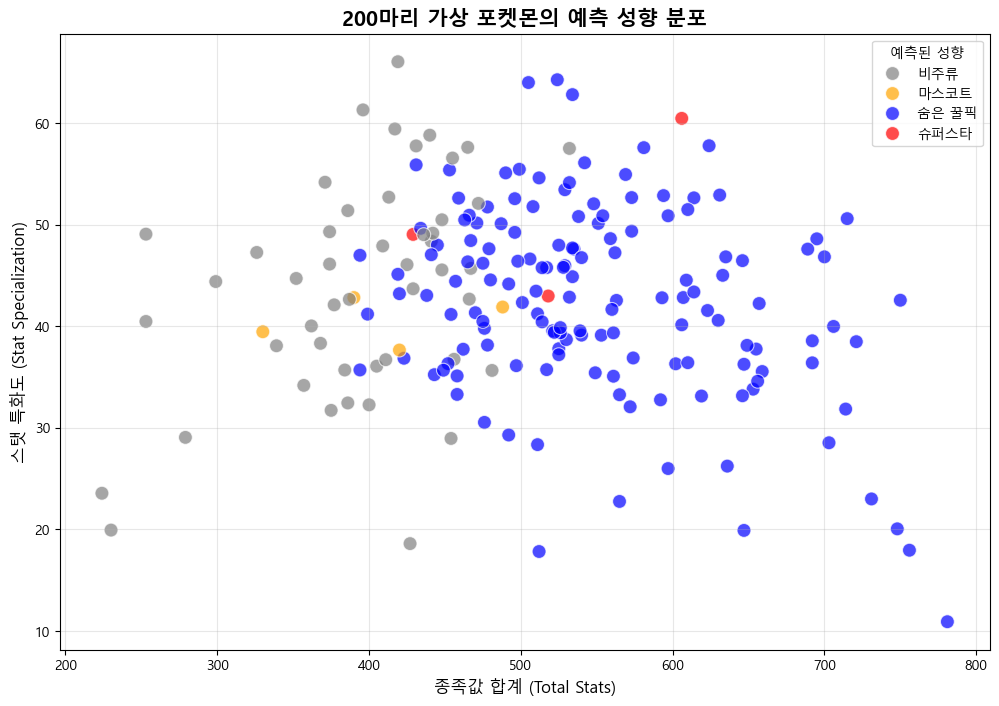


=== 가상 포켓몬 예측 요약 ===
Predicted_Group
숨은 꿀픽    145
비주류       48
마스코트       4
슈퍼스타       3
Name: count, dtype: int64


In [47]:

# 1. 200마리의 가상 포켓몬 데이터 생성
np.random.seed(42) # 결과 재현을 위한 시드 설정
n_samples = 200

# 수정된 가상 데이터 생성 (더 현실적인 범위)
data = {
    'name': [f"Imaginary_Pkm_{i+1}" for i in range(n_samples)],
    'hp': np.random.randint(10, 160, n_samples),      # 상한선을 160 -> 120으로 하향
    'attack': np.random.randint(10, 160, n_samples),
    'defense': np.random.randint(10, 160, n_samples),
    'sp_atk': np.random.randint(10, 160, n_samples),
    'sp_def': np.random.randint(10, 160, n_samples),
    'speed': np.random.randint(10, 160, n_samples),
    'Evolution_Stage': np.random.randint(0, 3, n_samples),
    'is_gen_1': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]), # 20%는 1세대로 설정
    'Is_Dual_Type': np.random.choice([0, 1], n_samples)
}

# 데이터프레임 변환
new_pkm_df = pd.DataFrame(data)

# 2. 파생 변수 계산
stat_cols = ['hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed']
new_pkm_df['total'] = new_pkm_df[stat_cols].sum(axis=1)
new_pkm_df['Stat_Specialization'] = new_pkm_df[stat_cols].std(axis=1)
new_pkm_df['is_evolved'] = (new_pkm_df['Evolution_Stage'] > 0).astype(int)
new_pkm_df['Physical_vs_Special'] = new_pkm_df['attack'] / (new_pkm_df['sp_atk'] + 1e-5)

# 3. 모델 예측을 위한 전처리
# 학습 때 사용했던 원핫 인코딩 컬럼들(type1_...)을 0으로 초기화하여 추가
X_predict = new_pkm_df.copy()
for col in X_train.columns:
    if col not in X_predict.columns:
        X_predict[col] = 0

# 컬럼 순서 일치 및 예측 수행
X_predict = X_predict[X_train.columns]
preds = final_rf_model.predict(X_predict)

# 결과 합치기
label_names = {0: '비주류', 1: '마스코트', 2: '숨은 꿀픽', 3: '슈퍼스타'}
new_pkm_df['Predicted_Group'] = [label_names[p] for p in preds]

# 4. 산점도 시각화
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=new_pkm_df, 
    x='total', 
    y='Stat_Specialization', 
    hue='Predicted_Group',
    hue_order=['비주류', '마스코트', '숨은 꿀픽', '슈퍼스타'],
    palette={'비주류': 'gray', '마스코트': 'orange', '숨은 꿀픽': 'blue', '슈퍼스타': 'red'},
    s=100, alpha=0.7
)

plt.title('200마리 가상 포켓몬의 예측 성향 분포', fontsize=15, fontweight='bold')
plt.xlabel('종족값 합계 (Total Stats)', fontsize=12)
plt.ylabel('스탯 특화도 (Stat Specialization)', fontsize=12)
plt.legend(title='예측된 성향')
plt.grid(True, alpha=0.3)
plt.show()

# 5. 결과 요약 출력
print("\n=== 가상 포켓몬 예측 요약 ===")
print(new_pkm_df['Predicted_Group'].value_counts())